### Scratch book: 
#### SQL Queries for college hockey stat exploration

### Setup - Depend - Ect.

In [1]:
import os
import sys
from pathlib import Path
import pandas as pd

import numpy as np
import requests
from bs4 import BeautifulSoup
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import matplotlib.font_manager as fm
from matplotlib.font_manager import FontProperties
from matplotlib.offsetbox import OffsetImage
from matplotlib.ticker import PercentFormatter
from matplotlib.ticker import ScalarFormatter
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from PIL import Image

import numpy as np

# Optional advanced stats support
try:
    from statsmodels.nonparametric.smoothers_lowess import lowess as sm_lowess
    from statsmodels.regression.quantile_regression import QuantReg
    _HAS_STATSMODELS = True
except Exception:
    sm_lowess = None
    QuantReg = None
    _HAS_STATSMODELS = False


import config

# ======= BASE PATHS =======
try:
    # Works when running as a script
    base_dir = Path(__file__).resolve().parent
except NameError:
    # Fallback for notebooks or interactive mode
    base_dir = Path.cwd()

# one directory up (your config.py lives here)
config_folder = base_dir.parent

# two directories up (for TEMP, data, images)
project_root = base_dir.parent.parent



# ======= DATA FOLDERS =======
temp_folder = project_root / "TEMP"
data_folder = project_root / "data"
roster_folder = data_folder / "player_info"
school_info_folder = data_folder / "school_info"

# ======= IMAGE FOLDERS =======
img_folder = project_root / "images"
logo_folder = img_folder / "logos"
background_folder = img_folder / "background"
plot_folder = project_root / "TEMP" / "IMAGE" / "scatter_plots"

# ======= IMPORT CONFIG =======
sys.path.insert(0, str(config_folder))
import config  # now you can import config.py

# ======= LOAD DATA =======
roster_file = roster_folder / "roster_10_30_25.csv"
roster_df = pd.read_csv(roster_file)
roster_df["Current Team"] = roster_df["Current Team"].replace("RPI", "Rensselaer")

print(roster_df.columns)

school_info_file = school_info_folder / "arena_school_info.csv"
school_info_df = pd.read_csv(school_info_file)

# Check the Config import
# print((config_folder / "config.py").read_text())

Index(['Current Team', 'Last_Name', 'First_Name', 'No', 'Position', 'Yr', 'Ht',
       'Wt', 'DOB', 'Hometown', 'Height_Inches', 'Draft_Year', 'NHL_Team',
       'D_Round', 'Last Team', 'League', 'City', 'State_Province', 'Country'],
      dtype='object')


### Connect to database

In [2]:
## Connect to database using the recent_clean_db path from config.py
import sqlite3

### CONFIG FILE NOT WORKING AS EXPECTED - MANUAL FIX ####
data_folder = ('../../data/db/')
# filename = '2025_Feb_13_CLEAN.db'
filename = 'Season_YTD.db'
recent_clean_db = data_folder + filename
########### END MANUAL FIX ###########

conn = sqlite3.connect(recent_clean_db)
cursor = conn.cursor()
print("Connected to database:", config.recent_clean_db)


Connected to database: ../../data/db/Season_YTD.db


In [3]:
pen = pd.read_sql("SELECT * FROM penalty_summary;", conn)
goals = pd.read_sql("SELECT * FROM scoring_summary;", conn)
games = pd.read_sql("SELECT Game_ID, Home_Team, Away_Team FROM game_details;", conn)
lines = pd.read_sql("SELECT Game_ID, Team, goalsT FROM linescore;", conn)


# ----------------------------
# Team name normalization (drop-in)
# ----------------------------
TEAM_ALIAS = {
    "Rensselaer": "RPI",
    "St. Thomas": "St Thomas",
    "St. Cloud State": "St Cloud State",
    "St. Lawrence": "St Lawrence",
    # add more as you bump into them
}

def canon_team(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return None
    s = str(x).strip()
    return TEAM_ALIAS.get(s, s)

# Apply to all team-name columns we use
for df, cols in [
    (pen,   ["Team"]),                 # <- if your penalty table uses a different column name, change it here
    (goals, ["Team"]),
    (games, ["Home_Team", "Away_Team"]),
    (lines, ["Team"]),
]:
    for c in cols:
        if c in df.columns:
            df[c] = df[c].map(canon_team)


# ----------------------------
# Helpers: time parsing (supports 1/2/3, and optionally OT if present)
# ----------------------------
def period_start_and_len(period):
    p = str(period).strip().lower()
    # Common variants: "1st", "1", "2nd", "3", "OT", "Overtime", etc.
    if p.startswith("1"): return 0, 1200
    if p.startswith("2"): return 1200, 1200
    if p.startswith("3"): return 2400, 1200
    if "ot" in p or "over" in p: return 3600, 300   # if you want OT
    return None, None

def mmss_to_sec(t):
    if pd.isna(t): return None
    s = str(t).strip()
    if ":" not in s: return None
    m, sec = s.split(":")
    try:
        return int(m) * 60 + int(sec)
    except:
        return None

def abs_time(period, time_str, include_ot=True):
    base, plen = period_start_and_len(period)
    if base is None: 
        return None
    if (base == 3600) and (not include_ot):
        return None
    sec = mmss_to_sec(time_str)
    if sec is None:
        return None
    # Treat "20:00" / "5:00" as horn, not a second before
    if plen is not None and sec == plen:
        return base + plen
    return base + sec


### Helper function to deal with double minor edge cases
def normalize_double_minor_rows(pen_g: pd.DataFrame, team_col="Team", player_col="Player"):
    """
    Merge cases where the same player takes two 2-min penalties at the same timestamp.
    Treat as one 4-min double minor (single manpower slot, cancellable in 2-min chunks).

    Returns a new DataFrame with an added boolean column: Is_DoubleMinor
    """
    pen_g = pen_g.copy()
    pen_g["Pen_Length"] = pd.to_numeric(pen_g["Pen_Length"], errors="coerce")

    if player_col not in pen_g.columns:
        # Can't do the merge without player identity
        pen_g["Is_DoubleMinor"] = False
        return pen_g

    # Identify rows that are exactly 2-min penalties
    two = pen_g[pen_g["Pen_Length"] == 2].copy()
    if two.empty:
        pen_g["Is_DoubleMinor"] = False
        return pen_g

    # Group by same team, same player, same timestamp
    key_cols = ["Game_ID", "Period", "Time", team_col, player_col]
    counts = two.groupby(key_cols).size().rename("n").reset_index()

    # We only merge the exact pattern: two 2-min penalties
    dm_keys = counts[counts["n"] == 2]
    if dm_keys.empty:
        pen_g["Is_DoubleMinor"] = False
        return pen_g

    # Build a set of keys for fast matching
    dm_keys_tuples = set(map(tuple, dm_keys[key_cols].values.tolist()))

    # Split into: rows to merge vs keep
    def is_dm_row(r):
        return (r["Pen_Length"] == 2) and (tuple(r[c] for c in key_cols) in dm_keys_tuples)

    to_merge = pen_g[pen_g.apply(is_dm_row, axis=1)].copy()
    keep = pen_g[~pen_g.apply(is_dm_row, axis=1)].copy()

    # Create ONE 4-min row per key
    # We'll take the first row as a template and override length
    merged_rows = (
        to_merge.sort_values(key_cols)
        .groupby(key_cols, as_index=False)
        .head(1)
        .copy()
    )
    merged_rows["Pen_Length"] = 4
    merged_rows["Is_DoubleMinor"] = True

    keep["Is_DoubleMinor"] = False

    out = pd.concat([keep, merged_rows], ignore_index=True)
    return out


# ----------------------------
# Penalty typing (cancellable vs not)
# ----------------------------
def penalty_seconds(pen_min):
    # Pen_Length stored as TEXT in your DB
    try:
        return int(float(pen_min)) * 60
    except:
        return None

def is_cancellable(pen_min):
    # Majors do not cancel; minors & double minors do.
    # If you later add misconducts etc., you can refine this.
    try:
        m = int(float(pen_min))
    except:
        return False
    return m in (2, 4)

# ----------------------------
# Event-driven strength simulator for ONE game
# ----------------------------
def simulate_strength_game(game_id, home, away, pen_g, goals_g, include_ot=True):
    """
    Returns:
      intervals: list of dicts with time spans and skater counts
      events: list of dicts with goal/penalty events (optional debugging)
    """
   
    ### Helper Functions To Filter out 10, 20, ect penalties so they don't affect the manpower timeline
    def affects_manpower(pen_min):
        """
        Return True if this penalty creates a skater deficit.
        """
        try:
            m = int(float(pen_min))
        except:
            return False

        # common manpower-affecting durations
        if m in (2, 4, 5):
            return True

        # everything else we treat as non-manpower by default (10 misconduct, 20 GM, etc.)
        return False

    def penalty_seconds(pen_min):
        try:
            return int(float(pen_min)) * 60
        except:
            return None

    def is_cancellable(pen_min):
        # Only minors/double-minors cancel on a PP goal
        try:
            m = int(float(pen_min))
        except:
            return False
        return m in (2, 4)


    # Build penalty-start events
    pen_events = []
    for _, r in pen_g.iterrows():
        t0 = abs_time(r["Period"], r["Time"], include_ot=include_ot)

        pen_len = r["Pen_Length"]
        if not affects_manpower(pen_len):
            # e.g., 10-minute misconduct, game misconduct, etc. -> ignore for skater counts
            continue

        dur = penalty_seconds(pen_len)
        if t0 is None or dur is None or dur <= 0:
            continue

        team = r["Team"]
        pen_events.append({
            "t": t0,
            "type": "PEN_START",
            "team": team,
            "dur": dur,
            "cancellable": is_cancellable(pen_len),
            "raw_len": pen_len,   # optional, helps debugging
            "is_double_minor": bool(r.get("Is_DoubleMinor", False)),
        })


    # Build goal events
    goal_events = []
    for _, r in goals_g.iterrows():
        tg = abs_time(r["Period"], r["Time"], include_ot=include_ot)
        if tg is None:
            continue
        goal_events.append({
            "t": tg,
            "type": "GOAL",
            "team": r["Team"],
        })

    # Sort events by time; if same second, process penalties before goals
    def sort_key(e):
        pri = 0 if e["type"] == "PEN_START" else 1
        return (e["t"], pri)
    events = sorted(pen_events + goal_events, key=sort_key)

    # State: per team penalty queues
    # running penalties count down; queued penalties wait until a slot opens
    state = {
        home: {"running": [], "queued": []},
        away: {"running": [], "queued": []},
    }

    def running_count(team):
        return len(state[team]["running"])

    def skaters(team):
        # max 2 skaters down
        return 5 - min(2, running_count(team))

    def start_penalty(team, dur, cancellable, is_double_minor=False):
        """
        dur is seconds.
        Double minor should be cancellable in 2-minute chunks (120s).
        """
        if is_double_minor or dur == 240:
            pen_obj = {"rem": dur, "cancellable": True, "chunks": [120, 120]}
        else:
            pen_obj = {"rem": dur, "cancellable": cancellable, "chunks": None}

        if len(state[team]["running"]) < 2:
            state[team]["running"].append(pen_obj)
        else:
            state[team]["queued"].append(pen_obj)


    def tick(dt):
        # advance time by dt seconds, reduce remaining on running penalties
        for team in (home, away):
            for p in state[team]["running"]:
                p["rem"] -= dt

    def pop_expired_and_promote():
        # remove expired running; promote queued into running as slots open
        for team in (home, away):
            # remove expired
            state[team]["running"] = [p for p in state[team]["running"] if p["rem"] > 0]
            # promote queued into open slots
            while len(state[team]["running"]) < 2 and state[team]["queued"]:
                state[team]["running"].append(state[team]["queued"].pop(0))

    def next_expiration_time(now):
        # time until next running penalty expires
        times = []
        for team in (home, away):
            for p in state[team]["running"]:
                times.append(p["rem"])
        if not times:
            return None
        dt_min = min(times)
        return now + max(0, dt_min)

    def cancel_one_minor(scored_on_team):
        """
        On an advantaged goal:
        - cancel ONE cancellable penalty
        - for a double minor (chunks=[120,120]), remove only one chunk (reduce by 120s)
        """
        cancellables = [p for p in state[scored_on_team]["running"] if p.get("cancellable")]
        if not cancellables:
            return False

        # pick the cancellable penalty with the least time remaining
        pmin = min(cancellables, key=lambda p: p["rem"])

        # Double minor: reduce by one chunk (120s) instead of removing completely
        if pmin.get("chunks"):
            if pmin["chunks"]:
                pmin["chunks"].pop(0)
                pmin["rem"] -= 120

            # If no time left, remove it
            if pmin["rem"] <= 0 or not pmin["chunks"]:
                state[scored_on_team]["running"].remove(pmin)
        else:
            # Normal minor: remove entirely
            state[scored_on_team]["running"].remove(pmin)

        # Promote queued penalties if slots open
        while len(state[scored_on_team]["running"]) < 2 and state[scored_on_team]["queued"]:
            state[scored_on_team]["running"].append(state[scored_on_team]["queued"].pop(0))

        return True


    # Simulation loop
    intervals = []
    debug_events = []

    now = 0
    end_of_game = 3600 + (300 if include_ot else 0)

    i = 0
    while now <= end_of_game:
        next_event_t = events[i]["t"] if i < len(events) else None
        next_exp_t = next_expiration_time(now)

        # choose next time to jump to
        candidates = [t for t in [next_event_t, next_exp_t, end_of_game] if t is not None]
        t_next = min(candidates) if candidates else end_of_game

        if t_next > now:
            # record interval with current skater counts
            intervals.append({
                "Game_ID": game_id,
                "t_start": now,
                "t_end": t_next,
                "home": home,
                "away": away,
                "home_skaters": skaters(home),
                "away_skaters": skaters(away),
            })
            tick(t_next - now)
            now = t_next
            pop_expired_and_promote()

        # process all events at this second (pen starts then goals due to sorting)
        while i < len(events) and events[i]["t"] == now:
            e = events[i]
            if e["type"] == "PEN_START":
                start_penalty(e["team"], e["dur"], e["cancellable"], is_double_minor=e.get("is_double_minor", False))
                debug_events.append({**e, "Game_ID": game_id})
                pop_expired_and_promote()

            elif e["type"] == "GOAL":
                scoring_team = e["team"]
                other_team = home if scoring_team == away else away

                # --- CAPTURE strength BEFORE any cancellation ---
                home_sk_before = skaters(home)
                away_sk_before = skaters(away)
                scoring_sk_before = skaters(scoring_team)
                other_sk_before = skaters(other_team)

                # Determine if this goal was scored while scoring team had a manpower advantage (pre-cancel)
                adv = (scoring_sk_before > other_sk_before)

                cancelled = False
                if adv:
                    cancelled = cancel_one_minor(other_team)

                # --- CAPTURE strength AFTER cancellation ---
                home_sk_after = skaters(home)
                away_sk_after = skaters(away)

                debug_events.append({
                    **e,
                    "Game_ID": game_id,
                    "scoring_team": scoring_team,
                    "other_team": other_team,
                    "home_skaters_before": home_sk_before,
                    "away_skaters_before": away_sk_before,
                    "home_skaters_after": home_sk_after,
                    "away_skaters_after": away_sk_after,
                    "advantaged_goal": adv,
                    "cancelled_minor": cancelled,
                })
                pop_expired_and_promote()

            i += 1

        if now == end_of_game:
            break

    return intervals, debug_events

# ----------------------------
# Build 5v3 opportunities across all games
# ----------------------------
pen["t_abs"] = pen.apply(lambda r: abs_time(r["Period"], r["Time"], include_ot=True), axis=1)
goals["t_abs"] = goals.apply(lambda r: abs_time(r["Period"], r["Time"], include_ot=True), axis=1)

# Keep only rows with usable time
pen2 = pen[pen["t_abs"].notna()].copy()
goals2 = goals[goals["t_abs"].notna()].copy()

opps = []

for _, gr in games.iterrows():
    gid = gr["Game_ID"]
    home = gr["Home_Team"]
    away = gr["Away_Team"]

    pen_g = pen2[pen2["Game_ID"] == gid]
    # Merge weirdly-recorded double minors (2+2 same player/time)
    pen_g = normalize_double_minor_rows(pen_g, team_col="Team", player_col="Player")
    
    goals_g = goals2[goals2["Game_ID"] == gid]

    intervals, dbg = simulate_strength_game(gid, home, away, pen_g, goals_g, include_ot=True)
    int_df = pd.DataFrame(intervals)
    if int_df.empty:
        continue

    # 5v3 for home: home has 5, away has 3
    int_df["home_5v3"] = (int_df["home_skaters"] == 5) & (int_df["away_skaters"] == 3)
    int_df["away_5v3"] = (int_df["away_skaters"] == 5) & (int_df["home_skaters"] == 3)

    # Helper: pull goals in a time window
    gg = goals_g.copy()
    gg["t_abs"] = gg["t_abs"].astype(int)

    # IMPORTANT:
    # A PP goal cancels a penalty at the *same* timestamp, so the 5v3 interval often ends at t==goal_time.
    # With half-open intervals [t_start, t_end), a goal at exactly t_end would be excluded.
    # Treat goal as occurring "just before" the state transition by shifting it back 1 second.
    gg["t_eff"] = (gg["t_abs"] - 1).clip(lower=0)

    def goals_in_window(team, t0, t1):
        return gg[(gg["Team"] == team) & (gg["t_eff"] >= t0) & (gg["t_eff"] < t1)].shape[0]

    # Identify continuous spans (opportunities)
    def add_spans(mask_col, advantaged_team, sh_team):
        sub = int_df[int_df[mask_col]].copy()
        if sub.empty:
            return
        sub = sub.sort_values("t_start")

        # merge contiguous/adjacent segments
        cur_s, cur_e = None, None
        for _, r in sub.iterrows():
            s, e = int(r["t_start"]), int(r["t_end"])
            if cur_s is None:
                cur_s, cur_e = s, e
            elif s <= cur_e:  # overlap/adjacent
                cur_e = max(cur_e, e)
            else:
                # finalize current span
                gf = goals_in_window(advantaged_team, cur_s, cur_e)
                ga = goals_in_window(sh_team, cur_s, cur_e)  # SH goals allowed during 5v3
                opps.append({
                    "Game_ID": gid,
                    "Adv_Team": advantaged_team,
                    "SH_Team": sh_team,
                    "t_start": cur_s,
                    "t_end": cur_e,
                    "duration_sec": cur_e - cur_s,
                    "GF_while_5v3": gf,
                    "GA_while_5v3": ga,
                    "Scored_on_5v3": gf > 0,
                    "Allowed_SH_on_5v3": ga > 0,
                })
                cur_s, cur_e = s, e

        # finalize last span
        gf = goals_in_window(advantaged_team, cur_s, cur_e)
        ga = goals_in_window(sh_team, cur_s, cur_e)
        opps.append({
            "Game_ID": gid,
            "Adv_Team": advantaged_team,
            "SH_Team": sh_team,
            "t_start": cur_s,
            "t_end": cur_e,
            "duration_sec": cur_e - cur_s,
            "GF_while_5v3": gf,
            "GA_while_5v3": ga,
            "Scored_on_5v3": gf > 0,
            "Allowed_SH_on_5v3": ga > 0,
        })

    add_spans("home_5v3", home, away)
    add_spans("away_5v3", away, home)

opps_53_df = pd.DataFrame(opps)

# ----------------------------
# Attach final W/L/T for advantaged team in each opportunity
# ----------------------------
lines["goalsT"] = pd.to_numeric(lines["goalsT"], errors="coerce")
score = lines[["Game_ID", "Team", "goalsT"]].copy()

opps_53_df = opps_53_df.merge(score, left_on=["Game_ID", "Adv_Team"], right_on=["Game_ID", "Team"], how="left") \
                       .rename(columns={"goalsT": "Adv_FinalGoals"}).drop(columns=["Team"], errors="ignore")

# opponent final goals
opps_53_df = opps_53_df.merge(score, left_on=["Game_ID", "SH_Team"], right_on=["Game_ID", "Team"], how="left") \
                       .rename(columns={"goalsT": "Opp_FinalGoals"}).drop(columns=["Team"], errors="ignore")

def wlt(a, b):
    if pd.isna(a) or pd.isna(b): return None
    if a > b: return "W"
    if a < b: return "L"
    return "T"

opps_53_df["Game_Result_for_Adv"] = opps_53_df.apply(lambda r: wlt(r["Adv_FinalGoals"], r["Opp_FinalGoals"]), axis=1)

# ----------------------------
# Team summary table (success + edge cases + outcomes)
# ----------------------------
if opps_53_df.empty:
    team_53_summary = pd.DataFrame()
else:
    g = opps_53_df.groupby("Adv_Team")

    team_53_summary = pd.DataFrame({
        "Opps_5v3": g.size(),
        "Opps_Scored": g["Scored_on_5v3"].sum(),
        "Opps_NoGoal": (g["Scored_on_5v3"].size() - g["Scored_on_5v3"].sum()),
        "ConvRate_anyGoal": g["Scored_on_5v3"].mean(),
        "GF_while_5v3": g["GF_while_5v3"].sum(),
        "GA_SH_while_5v3": g["GA_while_5v3"].sum(),
        "Opps_Allowed_SH": g["Allowed_SH_on_5v3"].sum(),
        "Avg_5v3_Duration_sec": g["duration_sec"].mean(),
        # “String two goals off a 5v3” proxy: scored during 5v3 AND had >=2 total goals
        # *during that same 5v3 span* (rare but catches oddities / same-second artifacts)
        "Opps_GF2plus_while_5v3": (opps_53_df["GF_while_5v3"] >= 2).groupby(opps_53_df["Adv_Team"]).sum(),
    }).fillna(0)

    # Game outcomes, split by whether they scored on the 5v3
    def wlt_counts(df):
        vc = df["Game_Result_for_Adv"].value_counts()
        return pd.Series({"W": int(vc.get("W", 0)), "L": int(vc.get("L", 0)), "T": int(vc.get("T", 0))})

    overall_wlt = opps_53_df.groupby("Adv_Team").apply(wlt_counts)
    scored_wlt = opps_53_df[opps_53_df["Scored_on_5v3"]].groupby("Adv_Team").apply(wlt_counts)
    noscore_wlt = opps_53_df[~opps_53_df["Scored_on_5v3"]].groupby("Adv_Team").apply(wlt_counts)

    # Join outcome splits
    overall_wlt.columns = [f"GameW_{c}" for c in overall_wlt.columns]  # GameW_W/GameW_L/GameW_T
    scored_wlt.columns = [f"ScoredW_{c}" for c in scored_wlt.columns]
    noscore_wlt.columns = [f"NoGoalW_{c}" for c in noscore_wlt.columns]

    team_53_summary = team_53_summary.join(overall_wlt, how="left") \
                                     .join(scored_wlt, how="left") \
                                     .join(noscore_wlt, how="left") \
                                     .fillna(0).astype({c: "int64" for c in team_53_summary.columns if c.endswith(("_W","_L","_T"))})

    # Sort by sample size then conversion
    team_53_summary = team_53_summary.sort_values(["Opps_5v3", "ConvRate_anyGoal"], ascending=[False, False])

# --- outputs ---
opps_53_df, team_53_summary


C:\Users\jbanc\AppData\Local\Temp\ipykernel_22384\2880046683.py:554: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  overall_wlt = opps_53_df.groupby("Adv_Team").apply(wlt_counts)
C:\Users\jbanc\AppData\Local\Temp\ipykernel_22384\2880046683.py:555: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  scored_wlt = opps_53_df[opps_53_df["Scored_on_5v3"]].groupby("Adv_Team").apply(wlt_counts)
C:\Users\jbanc\AppData\Loc

(                                        Game_ID          Adv_Team  \
 0       2025-10-03-Connecticut-Colorado College  Colorado College   
 1            2025-10-03-Minnesota Duluth-Alaska  Minnesota Duluth   
 2             2025-10-03-Merrimack-Mass. Lowell       Mass Lowell   
 3            2025-10-04-Lake Superior-Stonehill         Stonehill   
 4            2025-10-04-Lake Superior-Stonehill     Lake Superior   
 ..                                          ...               ...   
 227     2026-01-24-Long Island-Alaska Anchorage  Alaska Anchorage   
 228                2026-01-24-Lindenwood-Alaska            Alaska   
 229         2026-01-24-St. Thomas-Lake Superior         St Thomas   
 230  2026-01-24-Northern Michigan-Michigan Tech     Michigan Tech   
 231                  2026-01-24-Harvard-Cornell           Cornell   
 
                SH_Team  t_start  t_end  duration_sec  GF_while_5v3  \
 0          Connecticut     2129   2157            28             0   
 1              

#### Validate data transformation
- look for strangeness

In [4]:
def sec_to_mmss(sec):
    sec = int(sec)
    m = sec // 60
    s = sec % 60
    return f"{m:02d}:{s:02d}"

def abs_to_period_time(t_abs):
    # Supports Reg + OT in 5:00 chunks as coded earlier
    t = int(t_abs)
    if t < 1200:
        return "1", sec_to_mmss(t)
    if t < 2400:
        return "2", sec_to_mmss(t - 1200)
    if t < 3600:
        return "3", sec_to_mmss(t - 2400)
    return "OT", sec_to_mmss(t - 3600)


In [5]:
def validate_game(gid, include_ot=True, show_intervals=False, max_rows=250):
    # pull teams
    gr = games[games["Game_ID"] == gid]
    if gr.empty:
        print(f"Game_ID {gid} not found in game_details")
        return None

    home = gr.iloc[0]["Home_Team"]
    away = gr.iloc[0]["Away_Team"]

    # subset data
    pen_g = pen2[pen2["Game_ID"] == gid].copy()
    goals_g = goals2[goals2["Game_ID"] == gid].copy()

    # run sim
    intervals, dbg = simulate_strength_game(gid, home, away, pen_g, goals_g, include_ot=include_ot)

    int_df = pd.DataFrame(intervals)
    ev_df = pd.DataFrame(dbg)

    if ev_df.empty:
        print(f"No events found for {gid} ({away} at {home})")
        return None

    # Build a strength lookup by interval to annotate events
    # (tiny loop is fine per game; keeps it easy to reason about)
    def strength_at(t_abs):
        row = int_df[(int_df["t_start"] <= t_abs) & (t_abs < int_df["t_end"])].head(1)
        if row.empty:
            # if exact at horn etc.
            row = int_df[(int_df["t_start"] <= t_abs)].tail(1)
            if row.empty:
                return None
        r = row.iloc[0]
        return int(r["home_skaters"]), int(r["away_skaters"])

    # annotate events
    rows = []
    for _, e in ev_df.sort_values("t").iterrows():
        t = int(e["t"])
        per, tm = abs_to_period_time(t)
        hs_as = strength_at(t)
        if hs_as is None:
            hs = as_ = None
        else:
            hs, as_ = hs_as

        strength = None
        if hs is not None and as_ is not None:
            if hs == as_:
                strength = f"{hs}v{as_}"
            else:
                strength = f"{hs}v{as_}"

        if e["type"] == "PEN_START":
            team = e["team"]
            dur = e["dur"] // 60
            canc = "cancellable" if e.get("cancellable", False) else "noncancel"
            desc = f"PEN START: {team} ({dur} min, {canc})"
            flag = ""
        else:
            team = e["team"]
            # Determine if goal was SH during 5v3 at that moment
            flag_bits = []
            if hs is not None and as_ is not None:
                if team == home and hs == 3 and as_ == 5:
                    flag_bits.append("SH GOAL vs 5v3")
                if team == away and as_ == 3 and hs == 5:
                    flag_bits.append("SH GOAL vs 5v3")
            if e.get("advantaged_goal") is True:
                flag_bits.append("PP/ADV goal (cancel check)")
            if e.get("cancelled_minor") is True:
                flag_bits.append("cancelled minor")
            flag = " | ".join(flag_bits)

            desc = f"GOAL: {team}"

        rows.append({
            "AbsSec": t,
            "Period": per,
            "Time": tm,
            "HomeSk": hs,
            "AwaySk": as_,
            "Strength": strength,
            "Event": desc,
            "Flags": flag,
        })

    timeline = pd.DataFrame(rows).sort_values("AbsSec").head(max_rows)

    # Detect 5v3 spans and oddities
    if not int_df.empty:
        int_df = int_df.copy()
        int_df["home_5v3"] = (int_df["home_skaters"] == 5) & (int_df["away_skaters"] == 3)
        int_df["away_5v3"] = (int_df["away_skaters"] == 5) & (int_df["home_skaters"] == 3)

        def spans(mask):
            sub = int_df[int_df[mask]].sort_values("t_start")
            if sub.empty:
                return []
            out = []
            cur_s, cur_e = None, None
            for _, r in sub.iterrows():
                s, e = int(r["t_start"]), int(r["t_end"])
                if cur_s is None:
                    cur_s, cur_e = s, e
                elif s <= cur_e:
                    cur_e = max(cur_e, e)
                else:
                    out.append((cur_s, cur_e))
                    cur_s, cur_e = s, e
            out.append((cur_s, cur_e))
            return out

        home_spans = spans("home_5v3")
        away_spans = spans("away_5v3")

        def goals_in_span(team, s, e):
            gg = goals_g.copy()
            return gg[(gg["Team"] == team) & (gg["t_abs"] >= s) & (gg["t_abs"] < e)].shape[0]

        weird = []
        for s, e in home_spans:
            dur = e - s
            gf = goals_in_span(home, s, e)
            ga = goals_in_span(away, s, e)
            if dur > 300:
                weird.append(f"HOME 5v3 span {abs_to_period_time(s)}-{abs_to_period_time(e)} duration {dur}s (>300)")
            if ga > 0:
                weird.append(f"HOME had 5v3 but allowed {ga} goal(s) (SH goal event likely)")
            if gf >= 2:
                weird.append(f"HOME scored {gf} goals during one 5v3 span (multi-goal 5v3)")

        for s, e in away_spans:
            dur = e - s
            gf = goals_in_span(away, s, e)
            ga = goals_in_span(home, s, e)
            if dur > 300:
                weird.append(f"AWAY 5v3 span {abs_to_period_time(s)}-{abs_to_period_time(e)} duration {dur}s (>300)")
            if ga > 0:
                weird.append(f"AWAY had 5v3 but allowed {ga} goal(s) (SH goal event likely)")
            if gf >= 2:
                weird.append(f"AWAY scored {gf} goals during one 5v3 span (multi-goal 5v3)")

    else:
        weird = ["No intervals generated (?)"]

    # Print summary
    print(f"\n=== validate_game: {gid} | {away} at {home} ===")
    if weird:
        print("Weird flags:")
        for w in weird:
            print(" -", w)
    else:
        print("Weird flags: (none)")

    # Display timeline
    display(timeline)

    if show_intervals:
        display(int_df.head(200))

    return timeline, int_df, ev_df


##### Quick “find weird games” helper

In [6]:
def find_weird_53_games(opps_53_df, min_duration_over=300):
    if opps_53_df is None or opps_53_df.empty:
        return pd.DataFrame()

    weird = opps_53_df[
        (opps_53_df["GA_while_5v3"] > 0) |
        (opps_53_df["GF_while_5v3"] >= 2) |
        (opps_53_df["duration_sec"] > min_duration_over)
    ].copy()

    return weird.sort_values(["GA_while_5v3", "GF_while_5v3", "duration_sec"], ascending=False)

weird_games = find_weird_53_games(opps_53_df)
weird_games[["Game_ID", "Adv_Team", "SH_Team", "duration_sec", "GF_while_5v3", "GA_while_5v3"]].head(20)


,Game_ID,Adv_Team,SH_Team,duration_sec,GF_while_5v3,GA_while_5v3
82,2025-11-07-North Dakota-Omaha,North Dakota,Omaha,117,2,0
183,2026-01-09-Alaska-Cornell,Cornell,Alaska,102,2,0


## Step 2  - Establish Baselines

In [7]:


# --- choose which column is the penalized team in pen2 ---
PEN_TEAM_COL = "Penalized_Team" if "Penalized_Team" in pen2.columns else "Team"

# 5-minute majors only (ignore misconduct 10s etc.; you already fixed manpower penalties elsewhere)
maj = pen2.copy()
maj["Pen_Length_num"] = pd.to_numeric(maj["Pen_Length"], errors="coerce")
maj = maj[(maj["Pen_Length_num"] == 5) & maj["t_abs"].notna()].copy()

# Start/end for the 5-minute window
maj["start_sec"] = maj["t_abs"].astype(int)
maj["end_sec"] = maj["start_sec"] + 300
maj["major_id"] = np.arange(len(maj))

# Add home/away so we can identify PP team
maj = maj.merge(games, on="Game_ID", how="left")

# Penalized team and PP team
maj["pen_team"] = maj[PEN_TEAM_COL]
maj["pp_team"] = np.where(
    maj["pen_team"] == maj["Home_Team"], maj["Away_Team"],
    np.where(maj["pen_team"] == maj["Away_Team"], maj["Home_Team"], None)
)

maj = maj[maj["pp_team"].notna()].copy()

# Compute window goals (ANY goals by either team during the 5:00 window)
g = goals2[goals2["t_abs"].notna()].copy()
g["t_abs"] = g["t_abs"].astype(int)

# join PP-team goals
ppg = g.merge(
    maj[["major_id", "Game_ID", "pp_team", "start_sec", "end_sec"]],
    left_on=["Game_ID", "Team"],
    right_on=["Game_ID", "pp_team"],
    how="inner",
)
ppg = ppg[(ppg["t_abs"] >= ppg["start_sec"]) & (ppg["t_abs"] < ppg["end_sec"])]
pp_counts = ppg.groupby("major_id").size().rename("GF_window")

# join SH-team (penalized team) goals during same window (these are SH goals relative to the PP team)
shg = g.merge(
    maj[["major_id", "Game_ID", "pen_team", "start_sec", "end_sec"]],
    left_on=["Game_ID", "Team"],
    right_on=["Game_ID", "pen_team"],
    how="inner",
)
shg = shg[(shg["t_abs"] >= shg["start_sec"]) & (shg["t_abs"] < shg["end_sec"])]
sh_counts = shg.groupby("major_id").size().rename("GA_window")

# assemble major-opportunity table
major_opps = maj[["major_id", "Game_ID", "pp_team", "pen_team", "start_sec", "end_sec"]].copy()
major_opps = major_opps.join(pp_counts, on="major_id").join(sh_counts, on="major_id")
major_opps[["GF_window", "GA_window"]] = major_opps[["GF_window", "GA_window"]].fillna(0).astype(int)

major_opps["Scored_on_major"] = major_opps["GF_window"] > 0
major_opps["Allowed_SH_on_major"] = major_opps["GA_window"] > 0
major_opps["Goals_Diff_window"] = major_opps["GF_window"] - major_opps["GA_window"]

major_opps.head()


,major_id,Game_ID,pp_team,pen_team,start_sec,end_sec,GF_window,GA_window,Scored_on_major,Allowed_SH_on_major,Goals_Diff_window
0,0,2025-10-04-Lake Superior-Stonehill,Stonehill,Lake Superior,1497,1797,0,0,False,False,0
1,1,2025-10-04-Bemidji State-Alaska Anchorage,Bemidji State,Alaska Anchorage,501,801,0,0,False,False,0
2,2,2025-10-04-St. Thomas-St. Cloud State,St Thomas,St Cloud State,3243,3543,1,0,True,False,1
3,3,2025-10-04-Minnesota Duluth-Alaska,Alaska,Minnesota Duluth,602,902,0,0,False,False,0
4,4,2025-10-09-New Hampshire-Michigan State,New Hampshire,Michigan State,2753,3053,1,0,True,False,1


In [8]:
#### TOTAL MAJORS AND 5v3s IN THE DATASET WITH CONVERTION RATES ETC.

baseline_major = pd.DataFrame({
    "Total_Majors": [len(major_opps)],
    "Pct_With_Goal": [major_opps["Scored_on_major"].mean()],
    "Avg_GF_per_major": [major_opps["GF_window"].mean()],
    "Pct_2Plus_GF": [(major_opps["GF_window"] >= 2).mean()],
    "Pct_Allowed_SH": [major_opps["Allowed_SH_on_major"].mean()],
    "Avg_GoalDiff_during_window": [major_opps["Goals_Diff_window"].mean()],
})

baseline_major


,Total_Majors,Pct_With_Goal,Avg_GF_per_major,Pct_2Plus_GF,Pct_Allowed_SH,Avg_GoalDiff_during_window
0,167,0.359281,0.419162,0.053892,0.065868,0.353293


In [9]:
lines2 = lines.copy()
lines2["goalsT"] = pd.to_numeric(lines2["goalsT"], errors="coerce")

maj_out = major_opps.merge(lines2, left_on=["Game_ID", "pp_team"], right_on=["Game_ID", "Team"], how="left") \
                    .rename(columns={"goalsT": "pp_goals_final"}).drop(columns=["Team"], errors="ignore")

maj_out = maj_out.merge(lines2, left_on=["Game_ID", "pen_team"], right_on=["Game_ID", "Team"], how="left") \
                 .rename(columns={"goalsT": "opp_goals_final"}).drop(columns=["Team"], errors="ignore")

def wlt(pp, opp):
    if pd.isna(pp) or pd.isna(opp): return None
    if pp > opp: return "W"
    if pp < opp: return "L"
    return "T"

maj_out["Game_Result_for_PP"] = maj_out.apply(lambda r: wlt(r["pp_goals_final"], r["opp_goals_final"]), axis=1)

baseline_major_outcomes = (
    maj_out.dropna(subset=["Game_Result_for_PP"])
           .groupby("Scored_on_major")["Game_Result_for_PP"]
           .value_counts(normalize=True)
           .unstack(fill_value=0)
)

# add sample sizes
baseline_major_outcomes["N"] = maj_out.groupby("Scored_on_major").size()

# Reorder columns
baseline_major_outcomes = baseline_major_outcomes[["N", "W", "L", "T"]]

baseline_major_outcomes


Game_Result_for_PP,N,W,L,T
Scored_on_major,,,,
False,107,0.504673,0.448598,0.046729
True,60,0.650000,0.300000,0.050000


#### OTHER

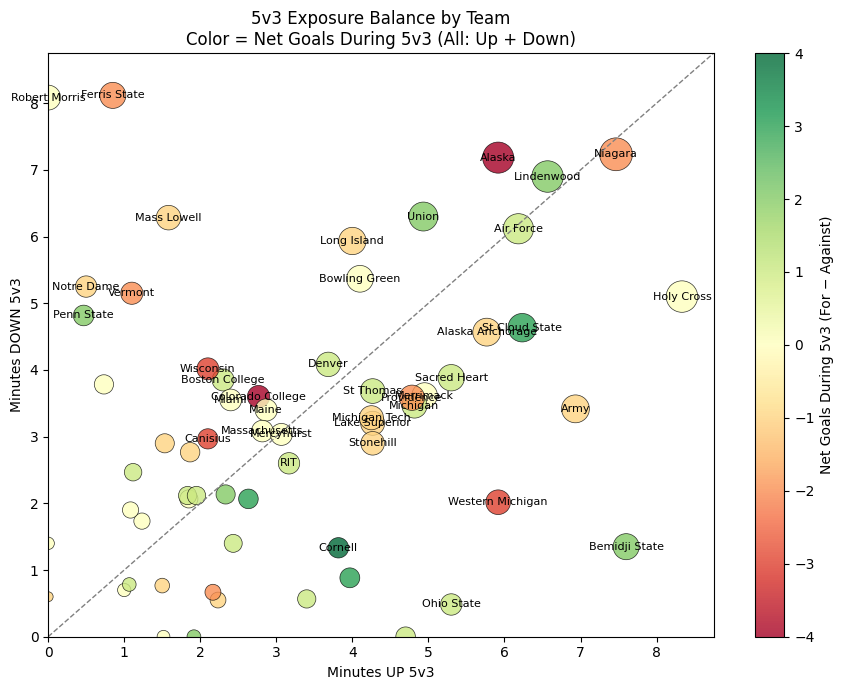

,Team,Time_UP_5v3_sec,Time_DOWN_5v3_sec,Goals_FOR_Up5v3,Goals_AGAINST_Up5v3,Goals_FOR_Down5v3,Goals_AGAINST_Down5v3,Total_5v3_Exposure_sec,Net_5v3_Time_sec,Goals_FOR_Total,Goals_AGAINST_Total,Net_Goals_5v3_Total,Time_UP_5v3_min,Time_DOWN_5v3_min,Total_5v3_Exposure_min,Net_5v3_Time_min,Goals_PER_Up5v3_min
38,Niagara,448.0,434.0,1.0,0.0,0.0,3.0,882.0,14.0,1.0,3.0,-2.0,7.466667,7.233333,14.700000,0.233333,0.133929
24,Lindenwood,394.0,414.0,2.0,0.0,0.0,0.0,808.0,-20.0,2.0,0.0,2.0,6.566667,6.900000,13.466667,-0.333333,0.304569
22,Holy Cross,500.0,306.0,1.0,0.0,0.0,1.0,806.0,194.0,1.0,1.0,0.0,8.333333,5.100000,13.433333,3.233333,0.120000
1,Alaska,355.0,431.0,0.0,0.0,0.0,4.0,786.0,-76.0,0.0,4.0,-4.0,5.916667,7.183333,13.100000,-1.266667,0.000000
0,Air Force,371.0,367.0,1.0,0.0,0.0,0.0,738.0,4.0,1.0,0.0,1.0,6.183333,6.116667,12.300000,0.066667,0.161725
56,Union,296.0,378.0,2.0,0.0,0.0,0.0,674.0,-82.0,2.0,0.0,2.0,4.933333,6.300000,11.233333,-1.366667,0.405405
52,St Cloud State,374.0,278.0,4.0,0.0,0.0,1.0,652.0,96.0,4.0,1.0,3.0,6.233333,4.633333,10.866667,1.600000,0.641711
4,Army,416.0,205.0,0.0,0.0,0.0,1.0,621.0,211.0,0.0,1.0,-1.0,6.933333,3.416667,10.350000,3.516667,0.000000
2,Alaska Anchorage,346.0,274.0,1.0,0.0,0.0,2.0,620.0,72.0,1.0,2.0,-1.0,5.766667,4.566667,10.333333,1.200000,0.173410
25,Long Island,240.0,356.0,1.0,0.0,0.0,2.0,596.0,-116.0,1.0,2.0,-1.0,4.000000,5.933333,9.933333,-1.933333,0.250000


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 5v3 Exposure + Goals table (coherent + correct)
# Uses opps_53_df with columns:
#   Adv_Team, SH_Team, duration_sec, GF_while_5v3, GA_while_5v3
# Where:
#   GF_while_5v3 = goals by Adv_Team during the 5v3 span
#   GA_while_5v3 = goals by SH_Team during the 5v3 span (i.e., SH goals against Adv_Team)
# ============================================================

required_cols = {"Adv_Team", "SH_Team", "duration_sec", "GF_while_5v3", "GA_while_5v3"}
missing = required_cols - set(opps_53_df.columns)
if missing:
    raise KeyError(f"opps_53_df missing required columns: {missing}")

df = opps_53_df.copy()

# Ensure numeric
df["duration_sec"] = pd.to_numeric(df["duration_sec"], errors="coerce").fillna(0).astype(int)
df["GF_while_5v3"] = pd.to_numeric(df["GF_while_5v3"], errors="coerce").fillna(0).astype(int)
df["GA_while_5v3"] = pd.to_numeric(df["GA_while_5v3"], errors="coerce").fillna(0).astype(int)

# ---- Exposure (time) ----
time_up = df.groupby("Adv_Team")["duration_sec"].sum().rename("Time_UP_5v3_sec")
time_down = df.groupby("SH_Team")["duration_sec"].sum().rename("Time_DOWN_5v3_sec")

# ---- Goals while UP 5v3 (Adv_Team perspective) ----
# For = Adv team's goals during 5v3
goals_for_up = df.groupby("Adv_Team")["GF_while_5v3"].sum().rename("Goals_FOR_Up5v3")
# Against = SH goals allowed during 5v3 (rare, but real)
goals_against_up = df.groupby("Adv_Team")["GA_while_5v3"].sum().rename("Goals_AGAINST_Up5v3")

# ---- Goals while DOWN 5v3 (SH_Team perspective) ----
# For = SH team's goals scored while down two (these are GA_while_5v3 from the Adv perspective)
goals_for_down = df.groupby("SH_Team")["GA_while_5v3"].sum().rename("Goals_FOR_Down5v3")
# Against = goals conceded while down two (these are GF_while_5v3 from the Adv perspective)
goals_against_down = df.groupby("SH_Team")["GF_while_5v3"].sum().rename("Goals_AGAINST_Down5v3")

# ---- Combine into one team table ----
exposure_53 = (
    pd.concat(
        [time_up, time_down, goals_for_up, goals_against_up, goals_for_down, goals_against_down],
        axis=1
    )
    .fillna(0)
    .reset_index()
    .rename(columns={"index": "Team"})
)

# If reset_index named the team column differently, fix it
if "Team" not in exposure_53.columns:
    # fallback: find the first non-metric column
    id_col = [c for c in exposure_53.columns if c not in {
        "Time_UP_5v3_sec","Time_DOWN_5v3_sec",
        "Goals_FOR_Up5v3","Goals_AGAINST_Up5v3",
        "Goals_FOR_Down5v3","Goals_AGAINST_Down5v3"
    }][0]
    exposure_53 = exposure_53.rename(columns={id_col: "Team"})

# ---- Totals / net ----
exposure_53["Total_5v3_Exposure_sec"] = exposure_53["Time_UP_5v3_sec"] + exposure_53["Time_DOWN_5v3_sec"]
exposure_53["Net_5v3_Time_sec"] = exposure_53["Time_UP_5v3_sec"] - exposure_53["Time_DOWN_5v3_sec"]

exposure_53["Goals_FOR_Total"] = exposure_53["Goals_FOR_Up5v3"] + exposure_53["Goals_FOR_Down5v3"]
exposure_53["Goals_AGAINST_Total"] = exposure_53["Goals_AGAINST_Up5v3"] + exposure_53["Goals_AGAINST_Down5v3"]
exposure_53["Net_Goals_5v3_Total"] = exposure_53["Goals_FOR_Total"] - exposure_53["Goals_AGAINST_Total"]

# ---- Minutes versions ----
exposure_53["Time_UP_5v3_min"] = exposure_53["Time_UP_5v3_sec"] / 60
exposure_53["Time_DOWN_5v3_min"] = exposure_53["Time_DOWN_5v3_sec"] / 60
exposure_53["Total_5v3_Exposure_min"] = exposure_53["Total_5v3_Exposure_sec"] / 60
exposure_53["Net_5v3_Time_min"] = exposure_53["Net_5v3_Time_sec"] / 60

# Optional: efficiency (only when UP)
exposure_53["Goals_PER_Up5v3_min"] = np.where(
    exposure_53["Time_UP_5v3_min"] > 0,
    exposure_53["Goals_FOR_Up5v3"] / exposure_53["Time_UP_5v3_min"],
    np.nan
)

# ============================================================
# Plot: Time UP vs Time DOWN, with color = Net Goals Total
# ============================================================
fig, ax = plt.subplots(figsize=(9, 7))

sizes = exposure_53["Total_5v3_Exposure_sec"] * 0.6 + 30

sc = ax.scatter(
    exposure_53["Time_UP_5v3_min"],
    exposure_53["Time_DOWN_5v3_min"],
    s=sizes,
    c=exposure_53["Net_Goals_5v3_Total"],
    cmap="RdYlGn",
    alpha=0.8,
    edgecolor="black",
    linewidth=0.5
)

max_lim = max(
    exposure_53["Time_UP_5v3_min"].max(),
    exposure_53["Time_DOWN_5v3_min"].max()
) * 1.05

ax.plot([0, max_lim], [0, max_lim], linestyle="--", color="gray", linewidth=1)
ax.set_xlim(0, max_lim)
ax.set_ylim(0, max_lim)

ax.set_xlabel("Minutes UP 5v3")
ax.set_ylabel("Minutes DOWN 5v3")
ax.set_title("5v3 Exposure Balance by Team\nColor = Net Goals During 5v3 (All: Up + Down)")

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Net Goals During 5v3 (For − Against)")

# Annotate teams with meaningful exposure (tweak threshold as you like)
for _, r in exposure_53.iterrows():
    if r["Total_5v3_Exposure_sec"] >= 300:  # 5+ total minutes in 5v3 situations
        ax.text(r["Time_UP_5v3_min"], r["Time_DOWN_5v3_min"], r["Team"],
                fontsize=8, ha="center", va="center")

plt.tight_layout()
plt.show()

# View the table
exposure_53.sort_values("Total_5v3_Exposure_sec", ascending=False).head(20)


# Notes on Major Pen and 5 on 3 Situational work

## Why Exposure Matters More Than Efficiency for Rare Events (Like 5v3)

When analyzing special teams situations such as **5-on-3 advantages**, it’s tempting to focus on efficiency metrics:

- Conversion rate  
- Goals per opportunity  
- Win percentage when scoring  

These metrics are intuitive — but for *rare events*, they can be deeply misleading.

---

### The Core Problem: Sample Size Collapse

5-on-3 situations are extremely uncommon in college hockey.

In a single season:

- Many teams have **zero** 5v3 opportunities  
- Most teams have **1–3 total** 5v3 spans  
- A handful of teams have meaningful exposure (5+ total minutes)

When sample sizes are this small:

- A single goal can swing a team from **0% → 100%**
- A single game outcome can define “Win% when scoring”
- Efficiency metrics become dominated by **noise**, not skill

In other words, efficiency answers the question:

> *“What happened in the few chances this team had?”*

But it does **not** reliably answer:

> *“How does this team typically play, or influence games?”*

---

### Exposure Is a Style and Discipline Signal

Exposure-based metrics shift the question from *results* to *process*.

Instead of asking:

- “Did this team score on 5v3?”

We ask:

- “How often does this team find itself **up (or down) two men**?”
- “How much **total time** do they spend in these extreme states?”

This captures:

- **Discipline** — avoiding unnecessary penalties  
- **Pressure** — forcing opponents into bad situations  
- **Game control** — tilting games into lopsided manpower states  

Time-based exposure is:

- More stable across seasons  
- Less sensitive to single events  
- More representative of team identity  

---

### Why We Start With Exposure, Then Layer in Goals

By first plotting:

- **Minutes UP 5v3 vs Minutes DOWN 5v3**

we establish a neutral baseline:

> *Who is actually involved in these situations, and on which side?*

Only **after** that baseline is understood does it make sense to layer in:

- Goals scored  
- Goals allowed  
- Net goal impact  

At that point, goals add **context**, not **distortion**.

This is why the primary 5v3 view in this notebook emphasizes:

- **Position** → exposure balance  
- **Size** → how often it happens  
- **Color** → what happened when it did  

Rather than ranking teams by efficiency alone.

---

### Takeaway

For rare events like 5v3:

- **Exposure tells you who teams are**
- **Efficiency tells you what happened once or twice**

Both matter — but in different orders.

This notebook intentionally prioritizes **exposure-first analysis** to avoid over-interpreting noise and to ensure that any efficiency insights are grounded in meaningful opportunity volume.

Future analyses (multi-season or conference-level) can safely reintroduce efficiency metrics once sample sizes grow.


In [11]:
breakpoint()

In [12]:
# baseline_53 = pd.DataFrame({
#     "Total_5v3_Opps": [len(opps_53_df)],
#     "Avg_5v3_Duration_sec": [opps_53_df["duration_sec"].mean()],
#     "Pct_5v3_With_Goal": [opps_53_df["Scored_on_5v3"].mean()],
#     "Pct_5v3_With_2Plus_Goals": [(opps_53_df["GF_while_5v3"] >= 2).mean()],
#     "Avg_Goals_Per_5v3": [opps_53_df["GF_while_5v3"].mean()],
#     "Pct_5v3_With_SH_Goal": [opps_53_df["Allowed_SH_on_5v3"].mean()],
# })

# baseline_53


In [13]:
# def outcome_baseline(df, success_col, result_col="Game_Result_for_Adv"):
#     out = (
#         df.groupby(success_col)[result_col]
#           .value_counts(normalize=True)
#           .unstack(fill_value=0)
#           .rename(columns={"W": "WinPct", "L": "LossPct", "T": "TiePct"})
#     )
#     out["Games"] = df.groupby(success_col).size()
#     return out

# baseline_53_outcomes = outcome_baseline(
#     opps_53_df,
#     success_col="Scored_on_5v3"
# )

# baseline_53_outcomes


### Build the team delta table

In [14]:
# ----------------------------
# Corrected leverage calculation
# ----------------------------
g = opps_53_df.copy()

def team_win_pct(df):
    vc = df["Game_Result_for_Adv"].value_counts()
    wins = vc.get("W", 0)
    losses = vc.get("L", 0)
    ties = vc.get("T", 0)
    total = wins + losses + ties
    if total == 0:
        return np.nan
    return (wins + 0.5 * ties) / total

rows = []

for team, df_team in g.groupby("Adv_Team"):
    opps = len(df_team)

    scored = df_team[df_team["Scored_on_5v3"]]
    noscore = df_team[~df_team["Scored_on_5v3"]]

    win_scored = team_win_pct(scored)
    win_noscore = team_win_pct(noscore)

    rows.append({
        "Adv_Team": team,
        "Opps_5v3": opps,
        "ConvRate_53": df_team["Scored_on_5v3"].mean(),
        "WinPct_Scored": win_scored,
        "WinPct_NoScore": win_noscore,
        "Leverage_Delta": (
            win_scored - win_noscore
            if pd.notna(win_scored) and pd.notna(win_noscore)
            else np.nan
        )
    })

team_53 = pd.DataFrame(rows)

# League average conversion rate (still valid X-axis)
league_conv_53 = baseline_53["Pct_5v3_With_Goal"].iloc[0]
team_53["ConvRate_Delta"] = team_53["ConvRate_53"] - league_conv_53

team_53


NameError: name 'baseline_53' is not defined

In [ ]:
# # ----------------------------
# # 5v3 exposure table (time-based)
# # ----------------------------

# # Time UP 5v3
# time_for = (
#     opps_53_df
#     .groupby("Adv_Team")["duration_sec"]
#     .sum()
#     .rename("Time_UP_5v3_sec")
# )

# # Time DOWN 5v3 (flip perspective)
# time_against = (
#     opps_53_df
#     .groupby("SH_Team")["duration_sec"]
#     .sum()
#     .rename("Time_DOWN_5v3_sec")
# )

# exposure_53 = pd.concat([time_for, time_against], axis=1).fillna(0).reset_index()
# exposure_53 = exposure_53.rename(columns={"index": "Team"})

# # Add total exposure + net balance
# exposure_53["Total_5v3_Exposure_sec"] = (
#     exposure_53["Time_UP_5v3_sec"] + exposure_53["Time_DOWN_5v3_sec"]
# )

# exposure_53["Net_5v3_Time_sec"] = (
#     exposure_53["Time_UP_5v3_sec"] - exposure_53["Time_DOWN_5v3_sec"]
# )

# # ----------------------------
# # Add goal data to 5v3 exposure table
# # ----------------------------

# # Goals FOR while UP 5v3
# goals_for = (
#     opps_53_df
#     .groupby("Adv_Team")["GF_while_5v3"]
#     .sum()
#     .rename("Goals_UP_5v3")
# )

# # Goals AGAINST while DOWN 5v3 (SH goals allowed)
# goals_against = (
#     opps_53_df
#     .groupby("SH_Team")["GA_while_5v3"]
#     .sum()
#     .rename("Goals_DOWN_5v3")
# )

# exposure_53 = (
#     exposure_53
#     .set_index("Team")
#     .join(goals_for, how="left")
#     .join(goals_against, how="left")
#     .fillna(0)
#     .reset_index()
# )

# # Net goals during 5v3
# exposure_53["Net_Goals_5v3"] = (
#     exposure_53["Goals_UP_5v3"] - exposure_53["Goals_DOWN_5v3"]
# )

# # # Optional: goals per minute UP 5v3 (soft efficiency signal)
# # exposure_53["Goals_per_5v3_min"] = np.where(
# #     exposure_53["Time_UP_5v3_min"] > 0,
# #     exposure_53["Goals_UP_5v3"] / exposure_53["Time_UP_5v3_min"],
# #     np.nan
# # )

# exposure_53.sort_values("Net_Goals_5v3", ascending=False).head()



In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 7))

sizes = exposure_53["Total_5v3_Exposure_sec"] * 0.6 + 30

ax.scatter(
    exposure_53["Time_UP_5v3_min"],
    exposure_53["Time_DOWN_5v3_min"],
    s=sizes,
    alpha=0.7,
    edgecolor="black",
    linewidth=0.5
)

# Diagonal reference: equal time up/down
max_lim = max(
    exposure_53["Time_UP_5v3_min"].max(),
    exposure_53["Time_DOWN_5v3_min"].max()
) * 1.05

ax.plot([0, max_lim], [0, max_lim], linestyle="--", color="gray", linewidth=1)

ax.set_xlim(0, max_lim)
ax.set_ylim(0, max_lim)

ax.set_xlabel("Minutes UP 5v3")
ax.set_ylabel("Minutes DOWN 5v3")
ax.set_title("5v3 Exposure Balance by Team\n(Time with Two-Man Advantage vs Disadvantage)")

# Annotate only teams with meaningful exposure
for _, r in exposure_53.iterrows():
    if r["Total_5v3_Exposure_sec"] >= 300:  # 5+ total minutes
        ax.text(
            r["Time_UP_5v3_min"],
            r["Time_DOWN_5v3_min"],
            r["Team"],
            fontsize=8,
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()


#### Question 1 - Team record after failing to convert on 5 minute PP, 5 on 3 PP

- Adam Nightengale asked this question during radio show - 1-26-26

In [ ]:


# # ----------------------------
# # Load tables
# # ----------------------------
# pen = pd.read_sql("SELECT * FROM penalty_summary;", conn)
# goals = pd.read_sql("SELECT Game_ID, Period, Time, Team FROM scoring_summary;", conn)
# games = pd.read_sql("SELECT Game_ID, Home_Team, Away_Team FROM game_details;", conn)
# lines = pd.read_sql("SELECT Game_ID, Team, goalsT FROM linescore;", conn)


# # --- Find which column in penalty_summary is the penalized team ---
# # common possibilities I've seen across your tables / scrapes
# candidate_cols = [
#     "Team", "TEAM",
#     "Penalized_Team", "PenalizedTeam", "Pen_Team",
#     "Against", "Against_Team",
# ]

# pen_team_col = next((c for c in candidate_cols if c in pen.columns), None)
# if pen_team_col is None:
#     raise KeyError(f"Couldn't find penalized-team column in penalty_summary. Columns are: {list(pen.columns)}")

# # Standardize to a known name
# pen = pen.rename(columns={pen_team_col: "Penalized_Team"})

# # ----------------------------
# # Canonicalize team names (adjust as needed)
# # ----------------------------
# alias = {
#     "Rensselaer": "RPI",
#     "St. Thomas": "St Thomas",
#     "St. Cloud State": "St Cloud State",
#     "St. Lawrence": "St Lawrence",
# }

# def canon(t):
#     if pd.isna(t):
#         return None
#     t = str(t).strip()
#     return alias.get(t, t)

# for df, col in [
#     (pen, "Penalized_Team"),
#     (goals, "Team"),
#     (games, "Home_Team"),
#     (games, "Away_Team"),
#     (lines, "Team"),
# ]:
#     df[col] = df[col].map(canon)


# # ----------------------------
# # Time helpers (regulation only)
# # ----------------------------
# def period_start(period):
#     p = str(period).strip().lower()
#     if p.startswith("1"): return 0
#     if p.startswith("2"): return 1200
#     if p.startswith("3"): return 2400
#     return None  # ignore OT/SO

# def to_seconds(t):
#     if pd.isna(t) or ":" not in str(t):
#         return None
#     m, s = str(t).strip().split(":")
#     try:
#         return int(m) * 60 + int(s)
#     except:
#         return None

# def abs_time(period, time_str):
#     base = period_start(period)
#     sec = to_seconds(time_str)
#     if base is None or sec is None:
#         return None
#     return base + sec

# pen["pen_min"] = pd.to_numeric(pen["Pen_Length"], errors="coerce")
# pen["start_sec"] = pen.apply(lambda r: abs_time(r["Period"], r["Time"]), axis=1)
# pen["end_sec"] = pen["start_sec"] + pen["pen_min"] * 60

# goals["goal_sec"] = goals.apply(lambda r: abs_time(r["Period"], r["Time"]), axis=1)

# # ----------------------------
# # Identify 5-minute majors & PP team
# # ----------------------------
# majors = pen[
#     (pen["pen_min"] == 5) &
#     pen["start_sec"].notna() &
#     pen["end_sec"].notna()
# ].copy()

# majors = majors.merge(games, on="Game_ID", how="left")

# # penalized team = majors["Team"]
# # power-play team = opponent of penalized team
# majors["pp_team"] = np.where(
#     majors["Penalized_Team"] == majors["Home_Team"], majors["Away_Team"],
#     np.where(majors["Penalized_Team"] == majors["Away_Team"], majors["Home_Team"], None)
# )


# majors = majors[majors["pp_team"].notna()].copy()
# majors["major_id"] = np.arange(len(majors))

# # ----------------------------
# # Flag: did PP team score ANY goal during the 5:00 window?
# # (no reliance on goal strength labels)
# # ----------------------------
# g = goals[goals["goal_sec"].notna()].copy()

# tmp = g.merge(
#     majors[["major_id", "Game_ID", "pp_team", "start_sec", "end_sec"]],
#     left_on=["Game_ID", "Team"],
#     right_on=["Game_ID", "pp_team"],
#     how="inner"
# )

# tmp["goal_during_major"] = (
#     (tmp["goal_sec"] >= tmp["start_sec"]) &
#     (tmp["goal_sec"] < tmp["end_sec"])
# )

# scored_any = tmp.groupby("major_id")["goal_during_major"].any().rename("scored_during_major")
# majors = majors.join(scored_any, on="major_id")
# majors["scored_during_major"] = majors["scored_during_major"].fillna(False)

# # ----------------------------
# # Attach final score & compute W/L/T for the PP team
# # ----------------------------
# lines["goalsT"] = pd.to_numeric(lines["goalsT"], errors="coerce")

# majors = majors.merge(
#     lines, left_on=["Game_ID", "pp_team"], right_on=["Game_ID", "Team"], how="left"
# ).rename(columns={"goalsT": "pp_goals"}).drop(columns=["Team"], errors="ignore")

# majors["opp_team"] = np.where(
#     majors["pp_team"] == majors["Home_Team"], majors["Away_Team"], majors["Home_Team"]
# )

# majors = majors.merge(
#     lines, left_on=["Game_ID", "opp_team"], right_on=["Game_ID", "Team"], how="left"
# ).rename(columns={"goalsT": "opp_goals"}).drop(columns=["Team"], errors="ignore")

# def outcome(pp, opp):
#     if pd.isna(pp) or pd.isna(opp):
#         return None
#     if pp > opp: return "W"
#     if pp < opp: return "L"
#     return "T"

# majors["result"] = majors.apply(lambda r: outcome(r["pp_goals"], r["opp_goals"]), axis=1)

# # ----------------------------
# # "Reverse" set: majors where PP team DID score during the 5:00 window
# # ----------------------------
# scored_on_major = majors[(majors["scored_during_major"]) & (majors["result"].notna())].copy()

# # Team W-L-T in those situations (per major instance)
# team_wlt_scored = (
#     scored_on_major.groupby("pp_team")["result"]
#     .value_counts()
#     .unstack(fill_value=0)
# )

# for c in ["W", "L", "T"]:
#     if c not in team_wlt_scored.columns:
#         team_wlt_scored[c] = 0
# team_wlt_scored = team_wlt_scored[["W", "L", "T"]].copy()

# team_wlt_scored["Majors_ScoredOn"] = team_wlt_scored["W"] + team_wlt_scored["L"] + team_wlt_scored["T"]
# team_wlt_scored["WinPct_(ties_half)"] = (team_wlt_scored["W"] + 0.5 * team_wlt_scored["T"]) / team_wlt_scored["Majors_ScoredOn"]

# # ----------------------------
# # QC counts: total 5-min majors FOR and AGAINST each team (regardless of scoring)
# # ----------------------------
# majors_for = majors["pp_team"].value_counts().rename("Majors_For")          # opponent took major vs you
# majors_against = majors["Penalized_Team"].value_counts().rename("Majors_Against")    # you took major

# out = team_wlt_scored.join(majors_for, how="left").join(majors_against, how="left").fillna(0)
# out[["Majors_For", "Majors_Against"]] = out[["Majors_For", "Majors_Against"]].astype(int)

# # Optional extra QC: how often did they score during the major, out of majors_for?
# scored_rate = (scored_on_major["pp_team"].value_counts() / majors_for).rename("ScoreDuringMajor_Rate")
# out = out.join(scored_rate, how="left").fillna({"ScoreDuringMajor_Rate": 0})

# # Sort: most samples first
# out = out.sort_values(["Majors_ScoredOn", "WinPct_(ties_half)"], ascending=[False, False])

# out


In [ ]:


# # ----------------------------
# # Load tables
# # ----------------------------
# pen = pd.read_sql("SELECT * FROM penalty_summary;", conn)
# goals = pd.read_sql("SELECT Game_ID, Period, Time, Team FROM scoring_summary;", conn)
# games = pd.read_sql("SELECT Game_ID, Home_Team, Away_Team FROM game_details;", conn)
# lines = pd.read_sql("SELECT Game_ID, Team, goalsT FROM linescore;", conn)

# # ----------------------------
# # Canonicalize team names
# # ----------------------------
# alias = {
#     "Rensselaer": "RPI",
#     "St. Thomas": "St Thomas",
#     "St. Cloud State": "St Cloud State",
#     "St. Lawrence": "St Lawrence",
# }

# def canon(t):
#     if pd.isna(t):
#         return None
#     t = str(t).strip()
#     return alias.get(t, t)

# for df, col in [
#     (pen, "Team"),
#     (goals, "Team"),
#     (games, "Home_Team"),
#     (games, "Away_Team"),
#     (lines, "Team"),
# ]:
#     df[col] = df[col].map(canon)

# # ----------------------------
# # Time helpers
# # ----------------------------
# def period_start(period):
#     p = str(period).lower()
#     if p.startswith("1"): return 0
#     if p.startswith("2"): return 1200
#     if p.startswith("3"): return 2400
#     return None  # ignore OT entirely

# def to_seconds(t):
#     if pd.isna(t) or ":" not in str(t):
#         return None
#     m, s = t.split(":")
#     return int(m) * 60 + int(s)

# def abs_time(row):
#     base = period_start(row["Period"])
#     sec = to_seconds(row["Time"])
#     if base is None or sec is None:
#         return None
#     return base + sec

# # ----------------------------
# # Build absolute timestamps
# # ----------------------------
# pen["start_sec"] = pen.apply(abs_time, axis=1)
# pen["pen_min"] = pd.to_numeric(pen["Pen_Length"], errors="coerce")
# pen["end_sec"] = pen["start_sec"] + pen["pen_min"] * 60

# goals["goal_sec"] = goals.apply(abs_time, axis=1)

# # ----------------------------
# # Filter to 5-minute majors
# # ----------------------------
# majors = pen[
#     (pen["pen_min"] == 5) &
#     pen["start_sec"].notna() &
#     pen["end_sec"].notna()
# ].copy()

# majors = majors.merge(games, on="Game_ID", how="left")

# # Power-play team = opponent of penalized team
# majors["pp_team"] = np.where(
#     majors["Team"] == majors["Home_Team"], majors["Away_Team"],
#     np.where(majors["Team"] == majors["Away_Team"], majors["Home_Team"], None)
# )

# majors["major_id"] = np.arange(len(majors))

# # ----------------------------
# # Join *all* goals by PP team
# # ----------------------------
# g = goals.merge(
#     majors[["major_id", "Game_ID", "pp_team", "start_sec", "end_sec"]],
#     left_on=["Game_ID", "Team"],
#     right_on=["Game_ID", "pp_team"],
#     how="inner"
# )

# # goal occurred during major window?
# g["goal_during_major"] = (
#     (g["goal_sec"] >= g["start_sec"]) &
#     (g["goal_sec"] < g["end_sec"])
# )

# scored = g.groupby("major_id")["goal_during_major"].any()

# majors = majors.join(scored, on="major_id")
# majors["scored_during_major"] = majors["goal_during_major"].fillna(False)

# # ----------------------------
# # Keep failures only
# # ----------------------------
# failed = majors[~majors["scored_during_major"]].copy()

# # ----------------------------
# # Attach final score and result
# # ----------------------------
# lines["goalsT"] = pd.to_numeric(lines["goalsT"], errors="coerce")

# failed = failed.merge(
#     lines, left_on=["Game_ID", "pp_team"], right_on=["Game_ID", "Team"],
#     how="left"
# ).rename(columns={"goalsT": "pp_goals"}).drop(columns=["Team"], errors="ignore")

# failed["opp_team"] = np.where(
#     failed["pp_team"] == failed["Home_Team"],
#     failed["Away_Team"],
#     failed["Home_Team"]
# )

# failed = failed.merge(
#     lines, left_on=["Game_ID", "opp_team"], right_on=["Game_ID", "Team"],
#     how="left"
# ).rename(columns={"goalsT": "opp_goals"}).drop(columns=["Team"], errors="ignore")

# def result(r):
#     if r["pp_goals"] > r["opp_goals"]: return "W"
#     if r["pp_goals"] < r["opp_goals"]: return "L"
#     return "T"

# failed["result"] = failed.apply(result, axis=1)

# ###
# # ----------------------------
# # Team-level record table
# # ----------------------------
# team_records = (
#     failed.groupby("pp_team")["result"]
#     .value_counts()
#     .unstack(fill_value=0)
# )

# # Ensure columns exist even if a result type is missing
# for c in ["W", "L", "T"]:
#     if c not in team_records.columns:
#         team_records[c] = 0

# team_records = team_records[["W", "L", "T"]].copy()

# # Add totals + a couple helpful rates
# team_records["Majors_Failed"] = team_records["W"] + team_records["L"] + team_records["T"]
# team_records["WinPct_(ties_half)"] = (team_records["W"] + 0.5 * team_records["T"]) / team_records["Majors_Failed"]

# # Optional: also count unique games (if multiple majors per game)
# team_records["Games_Failed"] = (
#     failed.groupby("pp_team")[["Game_ID"]]
#     .nunique()
#     .rename(columns={"Game_ID": "Games_Failed"})
# )

# # Sort: most majors first (or switch to WinPct if you want)
# team_records = team_records.sort_values(["Majors_Failed", "WinPct_(ties_half)"], ascending=[False, False])

# team_records.reset_index().rename(columns={"pp_team": "Team"}).round({"WinPct_(ties_half)": 3})

# team_records


# # ----------------------------
# # Summaries
# # ----------------------------
# per_major = failed["result"].value_counts().reindex(["W", "L", "T"]).fillna(0).astype(int)

# per_game = (
#     failed
#     .drop_duplicates(subset=["Game_ID", "pp_team"])
#     ["result"]
#     .value_counts()
#     .reindex(["W", "L", "T"])
#     .fillna(0)
#     .astype(int)
# )

# tmp = failed.merge(lines, left_on=["Game_ID", "pp_team"], right_on=["Game_ID", "Team"], how="left")
# print([c for c in tmp.columns if "Team" in c])


# print("Per major W-L-T:", f"{per_major['W']}-{per_major['L']}-{per_major['T']}", f"(N={len(failed)})")
# print("Per team-game W-L-T:", f"{per_game['W']}-{per_game['L']}-{per_game['T']}", f"(N={len(per_game)})")

# print(team_records.head(50))